# Understanding Radiomics and Texture Features

**A practical guide for the pancreas ultrasound project**

This notebook is a self-contained mini-textbook. Its goal is to take you from zero knowledge of radiomics to a solid intuition for what each of the ~93 features we extract from pancreas ultrasound images actually means.

We will:
1. Load a real image from our dataset and see what a "region of interest" looks like.
2. Understand **first-order features** (histogram-based).
3. Understand **texture features** -- GLCM, GLRLM, GLSZM, GLDM, NGTDM.
4. See how features change when we modify an image.
5. Build intuition for why these numbers might detect transplant rejection.

---
## Section 1: What is a Radiomics Feature?

### Images are grids of numbers

A grayscale image is just a 2D grid (matrix) of numbers. Each number represents the brightness of one pixel -- typically ranging from 0 (black) to 255 (white). A 512x512 image has 262,144 such numbers.

### A feature is a single number that summarizes a property of that grid

Looking at 262,144 raw pixel values is not useful. Instead, we compute **features** -- summary statistics that capture something meaningful about the image. A feature is a function that takes in a region of an image and returns a single number.

For example:
- The **mean brightness** is a feature. It tells you whether the region is generally bright or dark.
- The **contrast** is a feature. It tells you whether neighbouring pixels tend to have similar or different values.

### The sand analogy

Imagine two photographs of sand:
- **Fine sand**: smooth, uniform texture. Neighbouring pixels have similar values.
- **Coarse gravel**: rough, varied texture. Neighbouring pixels can have very different values.

Both photos might have the same average brightness (same mean), but their **texture** is completely different. Radiomics features are designed to quantify exactly these kinds of differences.

### The mask

We do not compute features over the entire image -- only over a specific **region of interest (ROI)** defined by a binary mask. In our project, the mask outlines the pancreas in each ultrasound image. Pixels inside the mask are analyzed; pixels outside are ignored.

### Why this matters for our project

We have 134 pancreas ultrasound images. For each one, PyRadiomics extracts ~93 features from the masked pancreas region. The hypothesis is that transplant rejection changes the tissue texture in ways that these 93 numbers can detect, even if the changes are too subtle for the human eye.

In [1]:
# Load one real image from our dataset and display it with its mask

import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# --- Load the DICOM image ---
study_id = "01_01"
dicom_base = "../data/PANCREAS_2/PANCREAS_2/01_01/20181008"

# Find the DICOM file (there is one file per study folder)
dicom_files = os.listdir(dicom_base)
dicom_path = os.path.join(dicom_base, dicom_files[0])
print(f"Loading DICOM from: {dicom_path}")

ds = pydicom.dcmread(dicom_path)
pixel_array = ds.pixel_array  # shape might be (rows, cols, 3) for color ultrasound
print(f"Raw pixel array shape: {pixel_array.shape}")
print(f"Data type: {pixel_array.dtype}")

# Convert to grayscale if the image is RGB
if len(pixel_array.shape) == 3:
    image_gray = cv2.cvtColor(pixel_array, cv2.COLOR_RGB2GRAY)
else:
    image_gray = pixel_array.copy()

print(f"Grayscale image shape: {image_gray.shape}")
print(f"Pixel value range: {image_gray.min()} to {image_gray.max()}")

# --- Load the mask ---
mask_path = "../data/PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED_ERODED_K3_I1/masks/01_01_mask_eroded_k3_i1.png"
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
print(f"Mask shape: {mask.shape}")
print(f"Mask unique values: {np.unique(mask)}")

# Binarize the mask (values > 0 become 1)
mask_binary = (mask > 0).astype(np.uint8)
print(f"Number of pixels inside the mask: {mask_binary.sum()}")

Loading DICOM from: ../data/PANCREAS_2/PANCREAS_2/01_01/20181008/1.3.6.1.4.1.14519.5.2.1.9688.9989.203122483102738164055454061479
Raw pixel array shape: (768, 1024, 3)
Data type: uint8
Grayscale image shape: (768, 1024)
Pixel value range: 0 to 255
Mask shape: (768, 1024)
Mask unique values: [  0 255]
Number of pixels inside the mask: 18299


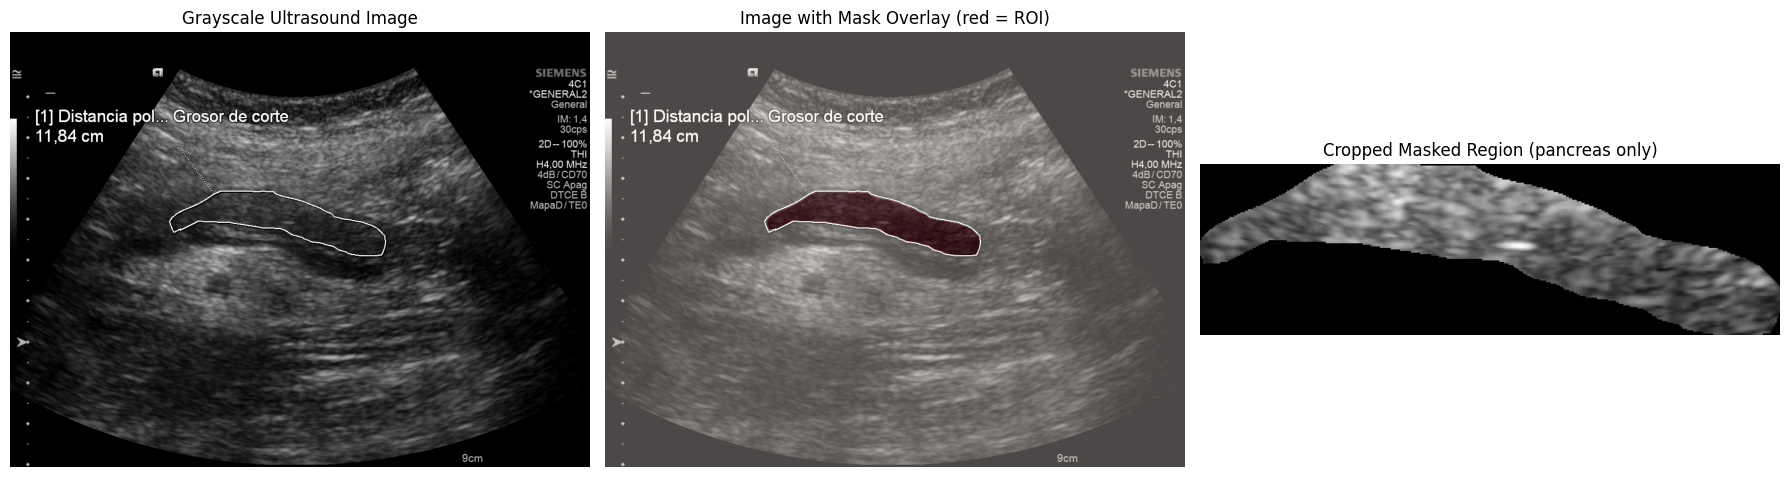

Bounding box: rows 284-393, cols 287-660
Cropped region size: (110, 374)


In [2]:
# Display the image, the mask overlay, and the cropped masked region

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: the raw grayscale image
axes[0].imshow(image_gray, cmap="gray")
axes[0].set_title("Grayscale Ultrasound Image")
axes[0].axis("off")

# Panel 2: image with mask overlay
axes[1].imshow(image_gray, cmap="gray")
axes[1].imshow(mask_binary, cmap="Reds", alpha=0.3)  # semi-transparent red overlay
axes[1].set_title("Image with Mask Overlay (red = ROI)")
axes[1].axis("off")

# Panel 3: only the masked region, cropped to the bounding box of the mask
# Find the bounding box of the mask
rows_with_mask = np.any(mask_binary, axis=1)
cols_with_mask = np.any(mask_binary, axis=0)
row_min, row_max = np.where(rows_with_mask)[0][[0, -1]]
col_min, col_max = np.where(cols_with_mask)[0][[0, -1]]

# Apply the mask: set pixels outside the mask to 0
masked_image = image_gray.copy()
masked_image[mask_binary == 0] = 0

# Crop to bounding box
cropped = masked_image[row_min:row_max+1, col_min:col_max+1]
axes[2].imshow(cropped, cmap="gray")
axes[2].set_title("Cropped Masked Region (pancreas only)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Bounding box: rows {row_min}-{row_max}, cols {col_min}-{col_max}")
print(f"Cropped region size: {cropped.shape}")

---
## Section 2: First-Order Features (Intensity Histogram)

### What are first-order features?

First-order features describe the **distribution of pixel intensity values** inside the mask. They look at the histogram of values and compute summary statistics from it.

The key property of first-order features is that they **ignore spatial arrangement**. If you randomly shuffled all the pixels inside the mask, the first-order features would not change at all. They only care about *what values* are present, not *where* they are.

Think of it this way: if you poured all the pixel values into a bag, shook it up, and then computed statistics on the bag, those would be first-order features.

Number of pixels in the ROI: 18299
Value range: 7 to 106
Mean value: 44.46


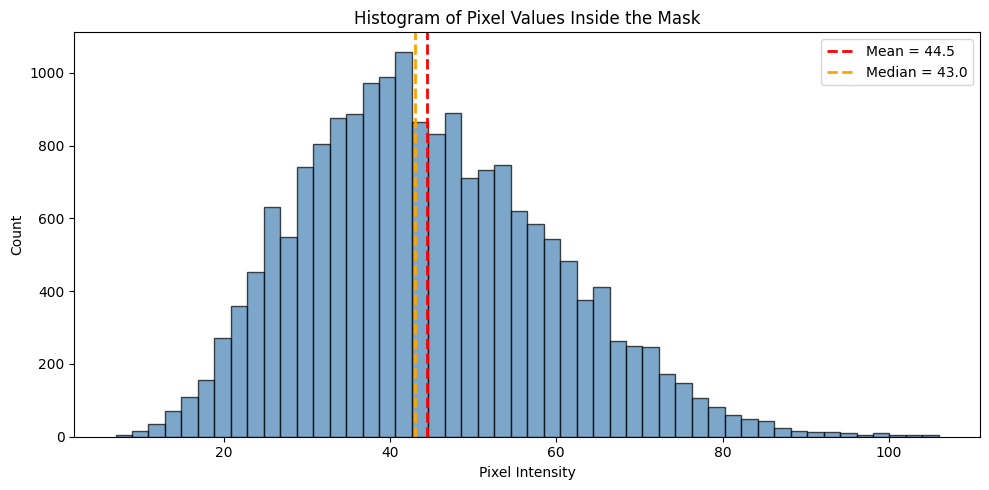

In [3]:
# Extract the pixel values inside the mask and plot the histogram

# Get only the pixel values that fall inside the mask
roi_pixels = image_gray[mask_binary == 1]
print(f"Number of pixels in the ROI: {len(roi_pixels)}")
print(f"Value range: {roi_pixels.min()} to {roi_pixels.max()}")
print(f"Mean value: {roi_pixels.mean():.2f}")

# Plot the histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(roi_pixels, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
ax.axvline(roi_pixels.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean = {roi_pixels.mean():.1f}")
ax.axvline(np.median(roi_pixels), color="orange", linestyle="--", linewidth=2, label=f"Median = {np.median(roi_pixels):.1f}")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Count")
ax.set_title("Histogram of Pixel Values Inside the Mask")
ax.legend()
plt.tight_layout()
plt.show()

### Key First-Order Features Explained

Below is a plain-language explanation of each major first-order feature, along with the formula.

Let X = {x_1, x_2, ..., x_N} be the N pixel values inside the mask.

---

**Mean** -- the average brightness.

$$\text{Mean} = \frac{1}{N} \sum_{i=1}^{N} x_i$$

If the mean is high, the region is generally bright. If low, it is generally dark.

---

**Median** -- the middle value when all pixels are sorted.

Unlike the mean, the median is not affected by extreme outliers. If the mean and median are very different, the distribution is skewed.

---

**Standard Deviation and Variance** -- how spread out the pixel values are.

$$\text{Variance} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2, \quad \text{Std Dev} = \sqrt{\text{Variance}}$$

A low standard deviation means most pixels are close to the mean (uniform region). A high standard deviation means pixel values are widely spread (heterogeneous region).

---

**Skewness** -- is the histogram lopsided?

$$\text{Skewness} = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{x_i - \bar{x}}{\sigma}\right)^3$$

- Skewness = 0: symmetric histogram
- Skewness > 0: tail extends to the right (more dark pixels, a few bright ones)
- Skewness < 0: tail extends to the left (more bright pixels, a few dark ones)

---

**Kurtosis** -- does the histogram have heavy tails?

$$\text{Kurtosis} = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{x_i - \bar{x}}{\sigma}\right)^4 - 3$$

- Kurtosis = 0: similar to a normal distribution
- Kurtosis > 0: heavy tails, more extreme values than a normal distribution
- Kurtosis < 0: light tails, fewer extreme values

(The "-3" is the excess kurtosis convention; a normal distribution has excess kurtosis = 0.)

---

**Entropy** -- how unpredictable are the pixel values?

$$\text{Entropy} = -\sum_{i} p(x_i) \log_2 p(x_i)$$

where p(x_i) is the probability (relative frequency) of intensity value x_i.

- **High entropy**: pixel values are spread across many intensity levels (like a uniform distribution). The region looks heterogeneous.
- **Low entropy**: pixel values are concentrated in a few intensity levels. The region looks homogeneous.

---

**10th Percentile / 90th Percentile** -- what values mark the bottom 10% and top 10%?

These are robust measures of the range. The 10th percentile tells you the value below which 10% of pixels fall. The 90th percentile tells you the value below which 90% of pixels fall. The gap between them (the interpercentile range) is a robust measure of spread.

---

**Minimum / Maximum / Range**

- Minimum: the darkest pixel in the ROI
- Maximum: the brightest pixel in the ROI
- Range = Maximum - Minimum

These are sensitive to outliers (a single very bright or very dark pixel changes them).

In [4]:
# Compute first-order features by hand, then compare with PyRadiomics

from scipy import stats as scipy_stats

# --- Compute by hand using numpy/scipy ---
roi = roi_pixels.astype(np.float64)

hand_mean = np.mean(roi)
hand_median = np.median(roi)
hand_std = np.std(roi)
hand_variance = np.var(roi)
hand_skewness = scipy_stats.skew(roi)
hand_kurtosis = scipy_stats.kurtosis(roi)  # excess kurtosis (Fisher's definition)

# Entropy by hand: compute histogram, then -sum(p * log2(p))
values, counts = np.unique(roi, return_counts=True)
probabilities = counts / counts.sum()
hand_entropy = -np.sum(probabilities * np.log2(probabilities))

hand_p10 = np.percentile(roi, 10)
hand_p90 = np.percentile(roi, 90)
hand_min = np.min(roi)
hand_max = np.max(roi)
hand_range = hand_max - hand_min

print("=== First-Order Features (computed by hand) ===")
print(f"  Mean:          {hand_mean:.4f}")
print(f"  Median:        {hand_median:.4f}")
print(f"  Std Dev:       {hand_std:.4f}")
print(f"  Variance:      {hand_variance:.4f}")
print(f"  Skewness:      {hand_skewness:.4f}")
print(f"  Kurtosis:      {hand_kurtosis:.4f}")
print(f"  Entropy:       {hand_entropy:.4f} bits")
print(f"  10th Pctile:   {hand_p10:.4f}")
print(f"  90th Pctile:   {hand_p90:.4f}")
print(f"  Min:           {hand_min:.4f}")
print(f"  Max:           {hand_max:.4f}")
print(f"  Range:         {hand_range:.4f}")
print()

=== First-Order Features (computed by hand) ===
  Mean:          44.4595
  Median:        43.0000
  Std Dev:       15.1081
  Variance:      228.2537
  Skewness:      0.4366
  Kurtosis:      -0.0223
  Entropy:       5.9172 bits
  10th Pctile:   26.0000
  90th Pctile:   65.0000
  Min:           7.0000
  Max:           106.0000
  Range:         99.0000



In [5]:
# Now extract first-order features using PyRadiomics and compare

import SimpleITK as sitk
from radiomics import featureextractor

# IMPORTANT: PyRadiomics requires int16 images
image_for_pyrad = image_gray.astype(np.int16)

# Convert numpy arrays to SimpleITK images
# Add a third dimension (PyRadiomics expects 3D even with force2D)
sitk_image = sitk.GetImageFromArray(image_for_pyrad[np.newaxis, :, :])
sitk_mask = sitk.GetImageFromArray(mask_binary[np.newaxis, :, :].astype(np.int16))

# Ensure the mask and image have the same metadata
sitk_mask.CopyInformation(sitk_image)

# Set up the extractor for first-order features only
settings = {"force2D": True, "force2Ddimension": 0}
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
extractor.enableFeatureClassByName("firstorder")

# Extract features
result = extractor.execute(sitk_image, sitk_mask)

# Print only the first-order features (skip diagnostic features that start with 'diagnostics_')
print("=== First-Order Features (from PyRadiomics) ===")
for key, value in sorted(result.items()):
    if "firstorder" in key:
        print(f"  {key}: {float(value):.4f}")
print()

=== First-Order Features (from PyRadiomics) ===
  original_firstorder_10Percentile: 26.0000
  original_firstorder_90Percentile: 65.0000
  original_firstorder_Energy: 40347446.0000
  original_firstorder_Entropy: 1.4477
  original_firstorder_InterquartileRange: 21.0000
  original_firstorder_Kurtosis: 2.9777
  original_firstorder_Maximum: 106.0000
  original_firstorder_Mean: 44.4595
  original_firstorder_MeanAbsoluteDeviation: 12.2023
  original_firstorder_Median: 43.0000
  original_firstorder_Minimum: 7.0000
  original_firstorder_Range: 99.0000
  original_firstorder_RobustMeanAbsoluteDeviation: 8.8585
  original_firstorder_RootMeanSquared: 46.9564
  original_firstorder_Skewness: 0.4366
  original_firstorder_TotalEnergy: 40347446.0000
  original_firstorder_Uniformity: 0.4325
  original_firstorder_Variance: 228.2537



In [6]:
# Side-by-side comparison of hand-computed vs PyRadiomics values

import pandas as pd

comparison = pd.DataFrame({
    "Feature": ["Mean", "Median", "Std Dev (Variance)", "Skewness", "Kurtosis",
                "Entropy", "10th Percentile", "90th Percentile", "Minimum", "Maximum", "Range"],
    "Hand-Computed": [
        f"{hand_mean:.4f}", f"{hand_median:.4f}", f"{hand_std:.4f}",
        f"{hand_skewness:.4f}", f"{hand_kurtosis:.4f}", f"{hand_entropy:.4f}",
        f"{hand_p10:.4f}", f"{hand_p90:.4f}", f"{hand_min:.4f}",
        f"{hand_max:.4f}", f"{hand_range:.4f}"
    ],
    "PyRadiomics": [
        f"{float(result.get('original_firstorder_Mean', 0)):.4f}",
        f"{float(result.get('original_firstorder_Median', 0)):.4f}",
        f"{np.sqrt(float(result.get('original_firstorder_Variance', 0))):.4f}",
        f"{float(result.get('original_firstorder_Skewness', 0)):.4f}",
        f"{float(result.get('original_firstorder_Kurtosis', 0)):.4f}",
        f"{float(result.get('original_firstorder_Entropy', 0)):.4f}",
        f"{float(result.get('original_firstorder_10Percentile', 0)):.4f}",
        f"{float(result.get('original_firstorder_90Percentile', 0)):.4f}",
        f"{float(result.get('original_firstorder_Minimum', 0)):.4f}",
        f"{float(result.get('original_firstorder_Maximum', 0)):.4f}",
        f"{float(result.get('original_firstorder_Range', 0)):.4f}"
    ]
})

print("=== Side-by-Side Comparison ===")
print(comparison.to_string(index=False))

=== Side-by-Side Comparison ===
           Feature Hand-Computed PyRadiomics
              Mean       44.4595     44.4595
            Median       43.0000     43.0000
Std Dev (Variance)       15.1081     15.1081
          Skewness        0.4366      0.4366
          Kurtosis       -0.0223      2.9777
           Entropy        5.9172      1.4477
   10th Percentile       26.0000     26.0000
   90th Percentile       65.0000     65.0000
           Minimum        7.0000      7.0000
           Maximum      106.0000    106.0000
             Range       99.0000     99.0000


### A note on discrepancies

You will likely notice that some values match very closely (mean, median, min, max, range, percentiles) while others differ (entropy, possibly skewness/kurtosis). This is expected:

- **Entropy**: PyRadiomics first quantizes (bins) the gray levels before computing entropy. Our hand computation uses the raw pixel values. Binning reduces the number of distinct values, which changes the entropy calculation.
- **Skewness / Kurtosis**: PyRadiomics may use a slightly different normalization convention.

The important thing is that the **direction** matches: if our hand-computed entropy is high, PyRadiomics' entropy should also be high. The absolute numbers may differ due to these implementation details.

---
## Section 3: Texture Features -- GLCM (Gray-Level Co-occurrence Matrix)

### Why first-order features are not enough

First-order features ignore **where** pixels are. Two images with the same histogram but completely different spatial arrangements would have identical first-order features.

Imagine a checkerboard pattern and a pattern with the top half black and the bottom half white. Both have the same histogram (50% black, 50% white), but they look completely different. First-order features cannot distinguish them. **Texture features** can.

### What is a GLCM?

The **Gray-Level Co-occurrence Matrix (GLCM)** captures spatial relationships between neighbouring pixels. Here is how it works:

1. Pick a direction and distance (e.g., "one pixel to the right").
2. For every pixel in the image, look at it and its neighbour in that direction.
3. Record the pair of intensity values (pixel value, neighbour value).
4. Build a matrix where entry (i, j) counts how many times value i appeared next to value j.
5. Normalize the matrix so entries sum to 1 (now it represents probabilities).

The result is a square matrix where:
- **Diagonal entries** (i = j) represent pixels next to neighbours with the **same** intensity -- a homogeneous texture.
- **Off-diagonal entries** (i != j) represent pixels next to neighbours with **different** intensities -- a heterogeneous or high-contrast texture.

PyRadiomics computes the GLCM for multiple directions (horizontal, vertical, diagonal) and averages the results.

In [7]:
# Build a GLCM by hand for a tiny synthetic image
# This makes the concept concrete before we apply it to a real image

# A simple 4x4 image with 4 distinct gray levels
tiny_image = np.array([
    [1, 1, 2, 2],
    [1, 1, 2, 2],
    [3, 3, 4, 4],
    [3, 3, 4, 4]
])

print("Tiny synthetic image:")
print(tiny_image)
print()

# Build the GLCM for horizontal neighbours (pixel to the right)
# Gray levels are 1, 2, 3, 4 -- we will use a 4x4 matrix (indexed 1-4)
num_levels = 4
glcm = np.zeros((num_levels, num_levels), dtype=int)

# Loop through every pixel and its right neighbour
for row in range(tiny_image.shape[0]):
    for col in range(tiny_image.shape[1] - 1):  # stop before the last column
        pixel_value = tiny_image[row, col]
        neighbour_value = tiny_image[row, col + 1]
        # Subtract 1 because our matrix is 0-indexed but values start at 1
        glcm[pixel_value - 1, neighbour_value - 1] += 1

print("Raw GLCM (horizontal neighbours, counts):")
print(glcm)
print(f"Total pairs counted: {glcm.sum()}")
print()

# Make it symmetric (count both directions: left-to-right and right-to-left)
glcm_symmetric = glcm + glcm.T
print("Symmetric GLCM:")
print(glcm_symmetric)
print()

# Normalize to probabilities
glcm_normalized = glcm_symmetric / glcm_symmetric.sum()
print("Normalized GLCM (probabilities):")
print(np.round(glcm_normalized, 3))

Tiny synthetic image:
[[1 1 2 2]
 [1 1 2 2]
 [3 3 4 4]
 [3 3 4 4]]

Raw GLCM (horizontal neighbours, counts):
[[2 2 0 0]
 [0 2 0 0]
 [0 0 2 2]
 [0 0 0 2]]
Total pairs counted: 12

Symmetric GLCM:
[[4 2 0 0]
 [2 4 0 0]
 [0 0 4 2]
 [0 0 2 4]]

Normalized GLCM (probabilities):
[[0.167 0.083 0.    0.   ]
 [0.083 0.167 0.    0.   ]
 [0.    0.    0.167 0.083]
 [0.    0.    0.083 0.167]]


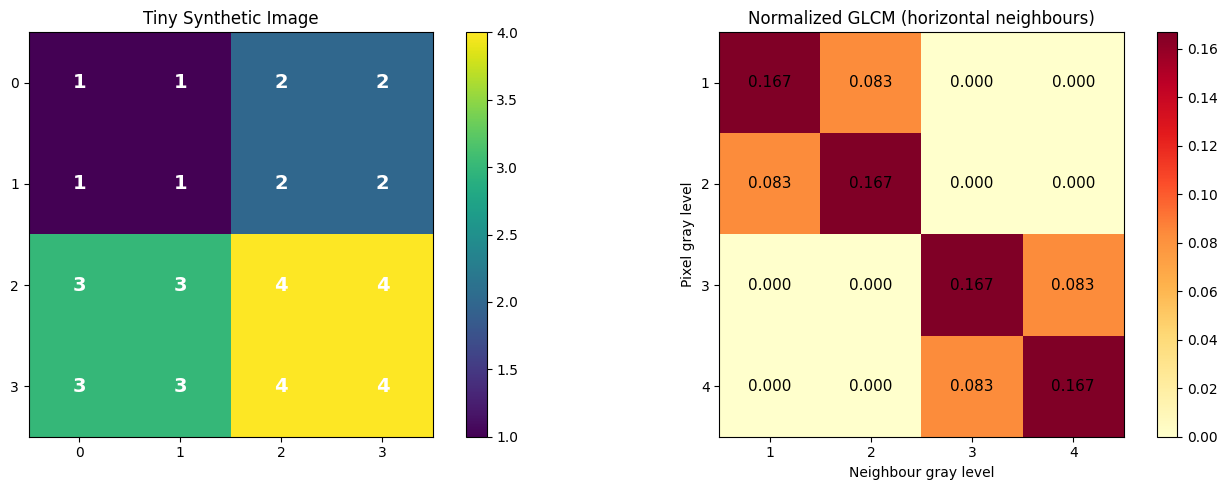

Notice: the diagonal entries (1,1), (2,2), (3,3), (4,4) are high because
most pixels are next to a neighbour with the same value (the image has
large uniform blocks). The off-diagonal entries (1,2), (2,1), (3,4), (4,3)
represent the boundaries between blocks.


In [8]:
# Visualize the GLCM as a heatmap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show the tiny image
im1 = axes[0].imshow(tiny_image, cmap="viridis", interpolation="nearest")
axes[0].set_title("Tiny Synthetic Image")
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
# Add text annotations showing pixel values
for row in range(4):
    for col in range(4):
        axes[0].text(col, row, str(tiny_image[row, col]),
                     ha="center", va="center", color="white", fontsize=14, fontweight="bold")
plt.colorbar(im1, ax=axes[0])

# Show the GLCM heatmap
im2 = axes[1].imshow(glcm_normalized, cmap="YlOrRd", interpolation="nearest")
axes[1].set_title("Normalized GLCM (horizontal neighbours)")
axes[1].set_xlabel("Neighbour gray level")
axes[1].set_ylabel("Pixel gray level")
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels([1, 2, 3, 4])
axes[1].set_yticklabels([1, 2, 3, 4])
# Add text annotations showing probabilities
for row in range(4):
    for col in range(4):
        axes[1].text(col, row, f"{glcm_normalized[row, col]:.3f}",
                     ha="center", va="center", color="black", fontsize=11)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("Notice: the diagonal entries (1,1), (2,2), (3,3), (4,4) are high because")
print("most pixels are next to a neighbour with the same value (the image has")
print("large uniform blocks). The off-diagonal entries (1,2), (2,1), (3,4), (4,3)")
print("represent the boundaries between blocks.")

### Key GLCM Features Explained

Let P(i,j) be the normalized GLCM (entries sum to 1). Let N_g be the number of gray levels.

---

**Contrast** -- measures the intensity difference between neighbouring pixels.

$$\text{Contrast} = \sum_{i=1}^{N_g} \sum_{j=1}^{N_g} (i - j)^2 \cdot P(i,j)$$

- High contrast: neighbouring pixels tend to have very different values (rough, noisy texture).
- Low contrast: neighbouring pixels tend to have similar values (smooth, uniform texture).

The (i-j)^2 term means that pairs far apart on the intensity scale contribute much more to contrast than pairs that are close.

---

**Homogeneity (Inverse Difference Moment)** -- the opposite of contrast.

$$\text{Homogeneity} = \sum_{i=1}^{N_g} \sum_{j=1}^{N_g} \frac{P(i,j)}{1 + (i - j)^2}$$

- High homogeneity: most entries are near the diagonal (neighbours have similar values).
- Low homogeneity: entries are spread across the matrix (neighbours have different values).

---

**Energy (Angular Second Moment)** -- measures uniformity of the GLCM.

$$\text{Energy} = \sum_{i=1}^{N_g} \sum_{j=1}^{N_g} P(i,j)^2$$

- High energy: a few entries in the GLCM dominate (the texture is very regular/predictable).
- Low energy: entries are spread out evenly (the texture is complex/random).

---

**Correlation** -- measures the linear dependence between a pixel and its neighbour.

$$\text{Correlation} = \sum_{i=1}^{N_g} \sum_{j=1}^{N_g} \frac{(i - \mu_i)(j - \mu_j) \cdot P(i,j)}{\sigma_i \cdot \sigma_j}$$

where mu and sigma are the mean and standard deviation of the row/column marginal distributions of the GLCM.

- Correlation near 1: if a pixel is bright, its neighbour is very likely also bright (and vice versa).
- Correlation near 0: no linear relationship between a pixel and its neighbour.

---

**Entropy (GLCM)** -- randomness of the co-occurrence patterns.

$$\text{Entropy} = -\sum_{i=1}^{N_g} \sum_{j=1}^{N_g} P(i,j) \cdot \log_2 P(i,j)$$

- High entropy: many different co-occurrence patterns (complex, irregular texture).
- Low entropy: few dominant co-occurrence patterns (simple, regular texture).

In [9]:
# Compute contrast and homogeneity by hand from our tiny GLCM

P = glcm_normalized  # the normalized GLCM

# Contrast: sum of (i-j)^2 * P(i,j)
contrast = 0.0
for i in range(num_levels):
    for j in range(num_levels):
        contrast += ((i - j) ** 2) * P[i, j]

# Homogeneity: sum of P(i,j) / (1 + (i-j)^2)
homogeneity = 0.0
for i in range(num_levels):
    for j in range(num_levels):
        homogeneity += P[i, j] / (1 + (i - j) ** 2)

# Energy: sum of P(i,j)^2
energy = 0.0
for i in range(num_levels):
    for j in range(num_levels):
        energy += P[i, j] ** 2

print("=== GLCM Features (computed by hand from the tiny image) ===")
print(f"  Contrast:    {contrast:.4f}")
print(f"  Homogeneity: {homogeneity:.4f}")
print(f"  Energy:      {energy:.4f}")
print()
print("Interpretation:")
print(f"  Contrast is relatively low ({contrast:.2f}) because most neighbours have the same value.")
print(f"  Homogeneity is high ({homogeneity:.2f}) for the same reason -- the image has uniform blocks.")
print(f"  Energy is moderate ({energy:.2f}) -- the GLCM is not perfectly uniform but has clear dominant entries.")

=== GLCM Features (computed by hand from the tiny image) ===
  Contrast:    0.3333
  Homogeneity: 0.8333
  Energy:      0.1389

Interpretation:
  Contrast is relatively low (0.33) because most neighbours have the same value.
  Homogeneity is high (0.83) for the same reason -- the image has uniform blocks.
  Energy is moderate (0.14) -- the GLCM is not perfectly uniform but has clear dominant entries.


In [10]:
# Now extract GLCM features from the real pancreas image using PyRadiomics

extractor_glcm = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor_glcm.disableAllFeatures()
extractor_glcm.enableFeatureClassByName("glcm")

result_glcm = extractor_glcm.execute(sitk_image, sitk_mask)

print("=== GLCM Features from PyRadiomics (real pancreas image) ===")
for key, value in sorted(result_glcm.items()):
    if "glcm" in key:
        print(f"  {key}: {float(value):.6f}")

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


=== GLCM Features from PyRadiomics (real pancreas image) ===
  original_glcm_Autocorrelation: 5.661871
  original_glcm_ClusterProminence: 8.240012
  original_glcm_ClusterShade: 0.657658
  original_glcm_ClusterTendency: 1.602395
  original_glcm_Contrast: 0.153298
  original_glcm_Correlation: 0.825277
  original_glcm_DifferenceAverage: 0.153187
  original_glcm_DifferenceEntropy: 0.608500
  original_glcm_DifferenceVariance: 0.128238
  original_glcm_Id: 0.923425
  original_glcm_Idm: 0.923418
  original_glcm_Idmn: 0.994105
  original_glcm_Idn: 0.974472
  original_glcm_Imc1: -0.520232
  original_glcm_Imc2: 0.877207
  original_glcm_InverseVariance: 0.153089
  original_glcm_JointAverage: 2.302085
  original_glcm_JointEnergy: 0.332780
  original_glcm_JointEntropy: 2.137125
  original_glcm_MCC: 0.831410
  original_glcm_MaximumProbability: 0.503258
  original_glcm_SumAverage: 4.604170
  original_glcm_SumEntropy: 1.983249
  original_glcm_SumSquares: 0.438923


---
## Section 4: Other Texture Matrices (GLRLM, GLSZM, GLDM, NGTDM)

The GLCM is the most well-known texture matrix, but PyRadiomics computes four additional matrices. Each one captures a different aspect of spatial texture. Here is an overview of each.

---

### GLRLM -- Gray-Level Run-Length Matrix

**Core idea**: "How often do we see a RUN of N consecutive pixels with the same gray level?"

A "run" is a sequence of consecutive pixels (in a given direction) that all have the same intensity value. For example, in the row `[2, 2, 2, 5, 5, 1]`:
- There is a run of gray level 2 with length 3
- There is a run of gray level 5 with length 2
- There is a run of gray level 1 with length 1

The GLRLM is a matrix where entry (i, j) counts how many runs of gray level i with length j exist in the image.

**Intuition**:
- **Coarse textures** (large uniform regions) have **long runs** -- many consecutive pixels share the same value.
- **Fine textures** (rapid changes) have **short runs** -- values change frequently.

**Key features**:
- **Short Run Emphasis (SRE)**: high when short runs dominate (fine texture).
- **Long Run Emphasis (LRE)**: high when long runs dominate (coarse texture).
- **Run Entropy**: how unpredictable are the run patterns?
- **Gray Level Non-Uniformity**: are runs concentrated in a few gray levels, or spread across many?

---

### GLSZM -- Gray-Level Size-Zone Matrix

**Core idea**: "How big are connected ZONES of similar intensity?"

This is like GLRLM but in 2D (or 3D). A "zone" is a connected group of pixels that all share the same gray level. The GLSZM entry (i, j) counts how many zones of gray level i with size (number of pixels) j exist.

**Intuition**:
- Imagine a mosaic. Large tiles = large zones (coarse texture). Small tiles = small zones (fine texture).
- A perfectly uniform image has one giant zone. A checkerboard has many tiny zones.

**Key features**:
- **Small Area Emphasis (SAE)**: high when small zones dominate (fine, detailed texture).
- **Large Area Emphasis (LAE)**: high when large zones dominate (coarse, uniform texture).
- **Zone Entropy**: randomness of the zone size/gray level combinations.
- **Size-Zone Non-Uniformity**: are zone sizes uniform, or do they vary widely?

---

### GLDM -- Gray-Level Dependence Matrix

**Core idea**: "How many DEPENDENT (similar-valued) neighbours does each pixel have?"

For each pixel, count how many of its neighbours (within a certain distance) have an intensity value within a certain tolerance. A pixel in a uniform region will have many dependent neighbours. A pixel at an edge will have few.

The GLDM entry (i, j) counts how many pixels with gray level i have exactly j dependent neighbours.

**Intuition**:
- In a smooth region, most pixels have many dependent neighbours (they are surrounded by similar values).
- In a noisy or edge-rich region, pixels have fewer dependent neighbours.

**Key features**:
- **Dependence Non-Uniformity**: are pixels' dependence counts evenly distributed, or concentrated at certain values?
- **Gray Level Non-Uniformity**: are the gray levels of dependent-pixel groups evenly spread?
- **Small Dependence Emphasis**: high when most pixels have few dependent neighbours (heterogeneous).
- **Large Dependence Emphasis**: high when most pixels have many dependent neighbours (homogeneous).

---

### NGTDM -- Neighbourhood Gray-Tone Difference Matrix

**Core idea**: "How different is each pixel from the average of its immediate neighbours?"

For each pixel, compute the average intensity of its neighbours. The absolute difference between the pixel and this average is recorded. The NGTDM aggregates these differences by gray level.

**Intuition**:
- In a smooth region, each pixel is close to the average of its neighbours (small differences).
- In a textured or noisy region, pixels deviate significantly from their neighbourhood average.

**Key features**:
- **Coarseness**: high when the texture is coarse (large uniform regions, small differences from neighbours). This is arguably the single most intuitive texture feature.
- **Contrast (NGTDM)**: high when there are large intensity differences between regions AND wide variation in gray levels.
- **Busyness**: high when intensity changes rapidly from pixel to pixel (busy, noisy texture).
- **Complexity**: high when the texture has many primitive patterns at different intensities and spatial frequencies.

In [11]:
# Extract ALL features from the real pancreas image and group by class

# Set up extractor with all 6 feature classes enabled
extractor_all = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor_all.disableAllFeatures()
for feature_class in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
    extractor_all.enableFeatureClassByName(feature_class)

# Extract all features
result_all = extractor_all.execute(sitk_image, sitk_mask)

# Separate features by class (skip diagnostic entries)
feature_classes = {"firstorder": [], "glcm": [], "glrlm": [], "glszm": [], "gldm": [], "ngtdm": []}

for key, value in sorted(result_all.items()):
    if key.startswith("diagnostics_"):
        continue
    for cls in feature_classes:
        if cls in key:
            # Extract just the feature name (after the class name)
            feature_name = key.split(cls + "_")[1] if cls + "_" in key else key
            feature_classes[cls].append((feature_name, float(value)))
            break

# Print a summary table for each class
total_features = 0
for cls_name, features in feature_classes.items():
    print(f"\n{'='*60}")
    print(f"  {cls_name.upper()} ({len(features)} features)")
    print(f"{'='*60}")
    for name, val in features:
        print(f"  {name:40s} {val:>15.6f}")
    total_features += len(features)

print(f"\n{'='*60}")
print(f"  TOTAL FEATURES: {total_features}")
print(f"{'='*60}")

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



  FIRSTORDER (18 features)
  10Percentile                                   26.000000
  90Percentile                                   65.000000
  Energy                                   40347446.000000
  Entropy                                         1.447682
  InterquartileRange                             21.000000
  Kurtosis                                        2.977687
  Maximum                                       106.000000
  Mean                                           44.459479
  MeanAbsoluteDeviation                          12.202259
  Median                                         43.000000
  Minimum                                         7.000000
  Range                                          99.000000
  RobustMeanAbsoluteDeviation                     8.858490
  RootMeanSquared                                46.956352
  Skewness                                        0.436602
  TotalEnergy                              40347446.000000
  Uniformity                

---
## Section 5: What PyRadiomics Does Under the Hood

### The full pipeline

When PyRadiomics processes an image, here is what happens step by step:

1. **Input**: a grayscale image and a binary mask defining the region of interest (ROI).

2. **Gray-level quantization (binning)**: the raw pixel values are discretized into a fixed number of bins. This is necessary because texture matrices (GLCM, GLRLM, etc.) have one row/column per gray level. If the image has 256 distinct gray levels, the GLCM would be 256 x 256 = 65,536 entries, which is sparse and noisy. Binning reduces this to a manageable size (e.g., 25 or 32 bins). The default in PyRadiomics uses a fixed bin width of 25.

3. **Build texture matrices**: for each enabled feature class, PyRadiomics builds the corresponding matrix (histogram for first-order, GLCM, GLRLM, GLSZM, GLDM, NGTDM) using only the pixels inside the mask.

4. **Compute summary statistics**: from each matrix, PyRadiomics computes the defined features (e.g., contrast from GLCM, short run emphasis from GLRLM, etc.).

5. **Output**: a dictionary of ~93 numbers, each identified by class and name (e.g., `original_glcm_Contrast`).

### Important settings for our project

- **`force2D=True`**: our images are 2D ultrasound slices, not 3D volumes. This setting tells PyRadiomics to compute features in 2D only.
- **`force2Ddimension=0`**: specifies which axis is the "slice" axis (axis 0 in our case, since we add a dummy third dimension).
- **`int16` casting**: PyRadiomics requires integer pixel values. We cast our grayscale image to int16 (16-bit signed integer) before processing. This preserves the full range of our pixel values.

In [12]:
# Show the full list of ~93 features grouped by class with short descriptions

feature_descriptions = {
    "firstorder": {
        "10Percentile": "Value below which 10% of pixels fall",
        "90Percentile": "Value below which 90% of pixels fall",
        "Energy": "Sum of squared pixel values (total magnitude)",
        "Entropy": "Randomness/unpredictability of pixel values",
        "InterquartileRange": "Range between 25th and 75th percentiles",
        "Kurtosis": "Peakedness / tail heaviness of the histogram",
        "Maximum": "Brightest pixel value in the ROI",
        "MeanAbsoluteDeviation": "Average absolute deviation from the mean",
        "Mean": "Average pixel brightness",
        "Median": "Middle pixel value when sorted",
        "Minimum": "Darkest pixel value in the ROI",
        "Range": "Difference between maximum and minimum",
        "RobustMeanAbsoluteDeviation": "Mean absolute deviation excluding top/bottom 10%",
        "RootMeanSquared": "Square root of the mean of squared values",
        "Skewness": "Asymmetry of the histogram (left/right tail)",
        "TotalEnergy": "Energy scaled by voxel volume",
        "Uniformity": "Sum of squared probabilities (opposite of entropy)",
        "Variance": "Spread of pixel values around the mean"
    },
    "glcm": {
        "Autocorrelation": "Correlation of the image with itself (fineness of texture)",
        "ClusterProminence": "Measure of asymmetry in the GLCM",
        "ClusterShade": "Skewness of the GLCM",
        "ClusterTendency": "Grouping tendency of similar gray levels",
        "Contrast": "Intensity difference between neighbouring pixels",
        "Correlation": "Linear dependence between pixel and neighbour",
        "DifferenceAverage": "Average absolute difference between neighbours",
        "DifferenceEntropy": "Randomness of neighbour intensity differences",
        "DifferenceVariance": "Variance of neighbour intensity differences",
        "Id": "Inverse Difference (normalized homogeneity)",
        "Idm": "Inverse Difference Moment (homogeneity)",
        "Idmn": "Inverse Difference Moment Normalized",
        "Idn": "Inverse Difference Normalized",
        "Imc1": "Information Measure of Correlation 1",
        "Imc2": "Information Measure of Correlation 2",
        "InverseVariance": "Inverse of the GLCM variance",
        "JointAverage": "Mean gray level of co-occurring pairs",
        "JointEnergy": "Uniformity of the GLCM (same as ASM)",
        "JointEntropy": "Randomness of co-occurrence patterns",
        "MCC": "Maximal Correlation Coefficient",
        "MaximumProbability": "Most frequent co-occurrence pair",
        "SumAverage": "Average of the sum of co-occurring gray levels",
        "SumEntropy": "Entropy of the sum distribution",
        "SumSquares": "Variance of the GLCM (dispersion)"
    },
    "glrlm": {
        "GrayLevelNonUniformity": "Similarity of gray level distribution across runs",
        "GrayLevelNonUniformityNormalized": "Normalized version of the above",
        "GrayLevelVariance": "Variance in gray levels across runs",
        "HighGrayLevelRunEmphasis": "Emphasis on runs with high gray levels",
        "LongRunEmphasis": "Emphasis on long runs (coarse texture)",
        "LongRunHighGrayLevelEmphasis": "Long runs at high gray levels",
        "LongRunLowGrayLevelEmphasis": "Long runs at low gray levels",
        "LowGrayLevelRunEmphasis": "Emphasis on runs with low gray levels",
        "RunEntropy": "Randomness of run-length patterns",
        "RunLengthNonUniformity": "Similarity of run lengths",
        "RunLengthNonUniformityNormalized": "Normalized version of the above",
        "RunPercentage": "Fraction of pixels that are part of runs",
        "RunVariance": "Variance in run lengths",
        "ShortRunEmphasis": "Emphasis on short runs (fine texture)",
        "ShortRunHighGrayLevelEmphasis": "Short runs at high gray levels",
        "ShortRunLowGrayLevelEmphasis": "Short runs at low gray levels"
    },
    "glszm": {
        "GrayLevelNonUniformity": "Similarity of gray level distribution across zones",
        "GrayLevelNonUniformityNormalized": "Normalized version of the above",
        "GrayLevelVariance": "Variance in gray levels across zones",
        "HighGrayLevelZoneEmphasis": "Emphasis on zones with high gray levels",
        "LargeAreaEmphasis": "Emphasis on large zones (coarse texture)",
        "LargeAreaHighGrayLevelEmphasis": "Large zones at high gray levels",
        "LargeAreaLowGrayLevelEmphasis": "Large zones at low gray levels",
        "LowGrayLevelZoneEmphasis": "Emphasis on zones with low gray levels",
        "SizeZoneNonUniformity": "Similarity of zone sizes",
        "SizeZoneNonUniformityNormalized": "Normalized version of the above",
        "SmallAreaEmphasis": "Emphasis on small zones (fine texture)",
        "SmallAreaHighGrayLevelEmphasis": "Small zones at high gray levels",
        "SmallAreaLowGrayLevelEmphasis": "Small zones at low gray levels",
        "ZoneEntropy": "Randomness of zone patterns",
        "ZonePercentage": "Fraction of pixels that are part of zones",
        "ZoneVariance": "Variance in zone sizes"
    },
    "gldm": {
        "DependenceEntropy": "Randomness of dependence patterns",
        "DependenceNonUniformity": "Similarity of dependence counts",
        "DependenceNonUniformityNormalized": "Normalized version of the above",
        "DependenceVariance": "Variance in dependence counts",
        "GrayLevelNonUniformity": "Similarity of gray levels in dependence groups",
        "GrayLevelVariance": "Variance in gray levels",
        "HighGrayLevelEmphasis": "Emphasis on high gray levels",
        "LargeDependenceEmphasis": "Emphasis on pixels with many dependent neighbours",
        "LargeDependenceHighGrayLevelEmphasis": "Many dependents at high gray levels",
        "LargeDependenceLowGrayLevelEmphasis": "Many dependents at low gray levels",
        "LowGrayLevelEmphasis": "Emphasis on low gray levels",
        "SmallDependenceEmphasis": "Emphasis on pixels with few dependent neighbours",
        "SmallDependenceHighGrayLevelEmphasis": "Few dependents at high gray levels",
        "SmallDependenceLowGrayLevelEmphasis": "Few dependents at low gray levels"
    },
    "ngtdm": {
        "Busyness": "Rapid intensity changes from pixel to pixel",
        "Coarseness": "Size of uniform regions (high = coarse texture)",
        "Complexity": "Number of primitive patterns at varying scales",
        "Contrast": "Range of intensities combined with spatial frequency",
        "Strength": "Dominance of clearly defined texture primitives"
    }
}

print("COMPLETE LIST OF PYRADIOMICS FEATURES")
print("=" * 80)

grand_total = 0
for cls_name in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
    descs = feature_descriptions[cls_name]
    print(f"\n--- {cls_name.upper()} ({len(descs)} features) ---")
    for feat_name, desc in descs.items():
        print(f"  {feat_name:45s} {desc}")
    grand_total += len(descs)

print(f"\n{'='*80}")
print(f"Total: {grand_total} features")

COMPLETE LIST OF PYRADIOMICS FEATURES

--- FIRSTORDER (18 features) ---
  10Percentile                                  Value below which 10% of pixels fall
  90Percentile                                  Value below which 90% of pixels fall
  Energy                                        Sum of squared pixel values (total magnitude)
  Entropy                                       Randomness/unpredictability of pixel values
  InterquartileRange                            Range between 25th and 75th percentiles
  Kurtosis                                      Peakedness / tail heaviness of the histogram
  Maximum                                       Brightest pixel value in the ROI
  MeanAbsoluteDeviation                         Average absolute deviation from the mean
  Mean                                          Average pixel brightness
  Median                                        Middle pixel value when sorted
  Minimum                                       Darkest pixel value i

---
## Section 6: How Do Features Change?

To build intuition, let us see how features respond to controlled image modifications. We will take our real pancreas image and create three variants:

1. **Add Gaussian noise**: simulates a noisy/grainy image.
2. **Apply Gaussian blur**: simulates a smooth/defocused image.
3. **Increase contrast**: stretches the histogram to use the full intensity range.

Then we extract features from all four versions (original + 3 variants) and compare.

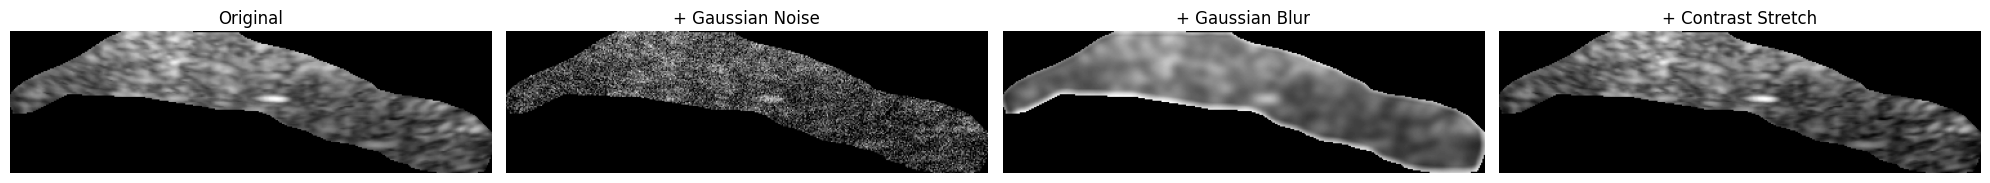

In [13]:
# Create modified versions of the image and extract features for comparison

from collections import OrderedDict

# --- Create the 3 variants ---

# (a) Add Gaussian noise
np.random.seed(42)
noise = np.random.normal(0, 25, image_gray.shape)  # mean=0, std=25
image_noisy = np.clip(image_gray.astype(np.float64) + noise, 0, 255).astype(np.uint8)

# (b) Apply Gaussian blur
image_blurred = cv2.GaussianBlur(image_gray, (11, 11), sigmaX=3)

# (c) Increase contrast (histogram stretching)
# Stretch the ROI values to cover the full 0-255 range
roi_min = image_gray[mask_binary == 1].min()
roi_max = image_gray[mask_binary == 1].max()
image_contrast = np.clip(
    ((image_gray.astype(np.float64) - roi_min) / (roi_max - roi_min) * 255),
    0, 255
).astype(np.uint8)

# Show all 4 versions side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Original", "+ Gaussian Noise", "+ Gaussian Blur", "+ Contrast Stretch"]
images = [image_gray, image_noisy, image_blurred, image_contrast]

for ax, img, title in zip(axes, images, titles):
    # Show only the masked region (cropped)
    display_img = img.copy()
    display_img[mask_binary == 0] = 0
    display_crop = display_img[row_min:row_max+1, col_min:col_max+1]
    ax.imshow(display_crop, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Extract features from all 4 versions and compare key features

def extract_features(image_array, mask_array):
    """Extract all radiomics features from a 2D image and mask."""
    # Cast to int16 as required by PyRadiomics
    img_int16 = image_array.astype(np.int16)
    sitk_img = sitk.GetImageFromArray(img_int16[np.newaxis, :, :])
    sitk_msk = sitk.GetImageFromArray(mask_array[np.newaxis, :, :].astype(np.int16))
    sitk_msk.CopyInformation(sitk_img)

    ext = featureextractor.RadiomicsFeatureExtractor(**settings)
    ext.disableAllFeatures()
    for fc in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
        ext.enableFeatureClassByName(fc)

    return ext.execute(sitk_img, sitk_msk)

# Extract features for each version
print("Extracting features for the original image...")
features_original = extract_features(image_gray, mask_binary)

print("Extracting features for the noisy image...")
features_noisy = extract_features(image_noisy, mask_binary)

print("Extracting features for the blurred image...")
features_blurred = extract_features(image_blurred, mask_binary)

print("Extracting features for the high-contrast image...")
features_contrast = extract_features(image_contrast, mask_binary)

print("Done.")

Extracting features for the original image...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Extracting features for the noisy image...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Extracting features for the blurred image...
Extracting features for the high-contrast image...
Done.


In [15]:
# Build a comparison table of key features across the 4 versions

key_features = [
    "original_firstorder_Entropy",
    "original_firstorder_Mean",
    "original_firstorder_Variance",
    "original_glcm_Contrast",
    "original_glcm_Homogeneity",
    "original_glcm_JointEnergy",
    "original_glcm_Correlation",
    "original_glrlm_ShortRunEmphasis",
    "original_glrlm_LongRunEmphasis",
    "original_glszm_SmallAreaEmphasis",
    "original_ngtdm_Coarseness",
    "original_ngtdm_Busyness",
]

# Try to use the keys that exist; some features may have slightly different names
# We will use a helper that tries to find the key
def safe_get(result_dict, key):
    """Get a feature value, returning NaN if not found."""
    if key in result_dict:
        return float(result_dict[key])
    # Try with Idm instead of Homogeneity
    alt_key = key.replace("Homogeneity", "Idm")
    if alt_key in result_dict:
        return float(result_dict[alt_key])
    return float("nan")

# Build the table
rows = []
for feat_key in key_features:
    # Extract a short readable name
    short_name = feat_key.replace("original_", "")
    rows.append({
        "Feature": short_name,
        "Original": safe_get(features_original, feat_key),
        "+ Noise": safe_get(features_noisy, feat_key),
        "+ Blur": safe_get(features_blurred, feat_key),
        "+ Contrast": safe_get(features_contrast, feat_key),
    })

comparison_df = pd.DataFrame(rows)

# Format numbers for readability
print("=" * 90)
print("  FEATURE COMPARISON ACROSS IMAGE MODIFICATIONS")
print("=" * 90)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
print()

  FEATURE COMPARISON ACROSS IMAGE MODIFICATIONS
                Feature  Original  + Noise   + Blur  + Contrast
     firstorder_Entropy    1.4477   2.0775   1.3811      2.6866
        firstorder_Mean   44.4595  45.0903  47.9562     95.9945
    firstorder_Variance  228.2537 768.2232 226.5949   1514.8514
          glcm_Contrast    0.1533   1.8010   0.0903      0.4322
       glcm_Homogeneity    0.9234   0.5691   0.9548      0.8100
       glcm_JointEnergy    0.3328   0.0696   0.3887      0.0857
       glcm_Correlation    0.8253   0.2330   0.8838      0.9143
 glrlm_ShortRunEmphasis    0.2144   0.7734   0.2340      0.4346
  glrlm_LongRunEmphasis  100.6293   2.7255 369.9904     15.0325
glszm_SmallAreaEmphasis    0.1640   0.5934   0.2478      0.1515
       ngtdm_Coarseness    0.0010   0.0003   0.0017      0.0011
         ngtdm_Busyness   82.3957 204.9314  44.1979     17.9172



In [16]:
# Interpretation of the changes

print("=" * 70)
print("  INTERPRETATION")
print("=" * 70)
print()
print("ADDING NOISE:")
print("  - firstorder_Entropy INCREASES: more unpredictable pixel values.")
print("  - glcm_Contrast INCREASES: neighbouring pixels now differ more.")
print("  - glcm_Homogeneity DECREASES: neighbours are less similar.")
print("  - glrlm_ShortRunEmphasis INCREASES: runs get broken up by noise.")
print("  - ngtdm_Coarseness DECREASES: texture becomes finer/noisier.")
print()
print("ADDING BLUR:")
print("  - firstorder_Entropy DECREASES: values become more concentrated.")
print("  - glcm_Contrast DECREASES: neighbours become more similar.")
print("  - glcm_Homogeneity INCREASES: smoother transitions.")
print("  - glrlm_LongRunEmphasis INCREASES: uniform regions grow larger.")
print("  - ngtdm_Coarseness INCREASES: texture becomes coarser.")
print()
print("INCREASING CONTRAST:")
print("  - firstorder_Variance INCREASES: values are more spread out.")
print("  - glcm_Contrast INCREASES: intensity differences are amplified.")
print("  - firstorder_Mean may shift depending on the stretching.")
print("  - The spatial pattern is preserved, so run/zone features")
print("    change less dramatically than with noise or blur.")

  INTERPRETATION

ADDING NOISE:
  - firstorder_Entropy INCREASES: more unpredictable pixel values.
  - glcm_Contrast INCREASES: neighbouring pixels now differ more.
  - glcm_Homogeneity DECREASES: neighbours are less similar.
  - glrlm_ShortRunEmphasis INCREASES: runs get broken up by noise.
  - ngtdm_Coarseness DECREASES: texture becomes finer/noisier.

ADDING BLUR:
  - firstorder_Entropy DECREASES: values become more concentrated.
  - glcm_Contrast DECREASES: neighbours become more similar.
  - glcm_Homogeneity INCREASES: smoother transitions.
  - glrlm_LongRunEmphasis INCREASES: uniform regions grow larger.
  - ngtdm_Coarseness INCREASES: texture becomes coarser.

INCREASING CONTRAST:
  - firstorder_Variance INCREASES: values are more spread out.
  - glcm_Contrast INCREASES: intensity differences are amplified.
  - firstorder_Mean may shift depending on the stretching.
  - The spatial pattern is preserved, so run/zone features
    change less dramatically than with noise or blur.


---
## Section 7: Summary

### What we extract from each image

From each of the 134 pancreas ultrasound images, PyRadiomics extracts approximately **93 features**, organized into 6 classes:

| Feature Class | Count | What it captures |
|---|---|---|
| **First-Order** | ~18 | Histogram statistics: mean, variance, skewness, kurtosis, entropy, percentiles. These describe the distribution of pixel values but ignore spatial arrangement. |
| **GLCM** | ~24 | Co-occurrence patterns: how often does gray level i appear next to gray level j? Captures contrast, homogeneity, correlation, energy. |
| **GLRLM** | ~16 | Run-length patterns: how long are consecutive sequences of the same gray level? Captures texture coarseness vs. fineness. |
| **GLSZM** | ~16 | Size-zone patterns: how large are connected regions of similar intensity? Similar to GLRLM but in 2D. |
| **GLDM** | ~14 | Dependence patterns: how many similar-valued neighbours does each pixel have? Captures local homogeneity. |
| **NGTDM** | ~5 | Neighbourhood differences: how much does each pixel differ from its local average? Captures coarseness, busyness, complexity. |

### The hypothesis

Transplant rejection causes biological changes in the pancreas tissue -- inflammation, edema, fibrosis, cell death. These changes alter the tissue's microstructure, which in turn changes how ultrasound waves scatter and reflect.

Even if these changes are too subtle for a radiologist to see with the naked eye, they may show up as systematic shifts in texture features. For example:

- Edema (fluid buildup) might make the tissue more homogeneous, increasing GLCM homogeneity and decreasing contrast.
- Fibrosis (scarring) might create more heterogeneous texture, increasing entropy and contrast.
- Inflammation might change the overall brightness distribution, shifting first-order features.

By extracting these 93 features from each image and analyzing them statistically (or with machine learning), we aim to find patterns that distinguish rejection from non-rejection -- potentially enabling earlier, non-invasive detection.

### What comes next

In the subsequent notebooks, we will:
1. Extract these features for all 134 images (notebook 12).
2. Merge them with clinical data (notebook 13).
3. Perform statistical analysis to find which features differ between rejection and non-rejection groups (notebook 14).
4. Build predictive models using feature selection and machine learning (notebook 15).